<>:157: SyntaxWarning: invalid escape sequence '\d'
<>:157: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2204/1411671130.py:157: SyntaxWarning: invalid escape sequence '\d'
  plt.yticks(ticks=np.arange(A.shape[0]), labels=[f"$\dot{{v}}_{{{i+1}}}$" for i in range(A.shape[0])])


Original Hankel Matrix Shape: (8, 5000)
U Matrix Shape : (8, 8)
s Matrix Shape : (8,)
V Matrix Shape : (8, 5000)
U Matrix R rank Shape : (8, 4)
s Matrix R rank Shape : (4,)
V Matrix R rank Shape : (4, 5000)
Shape of U matrix: (8, 8)
 Shape of s matrix: (8,) 
 Shape of V matrix: (8, 5000)


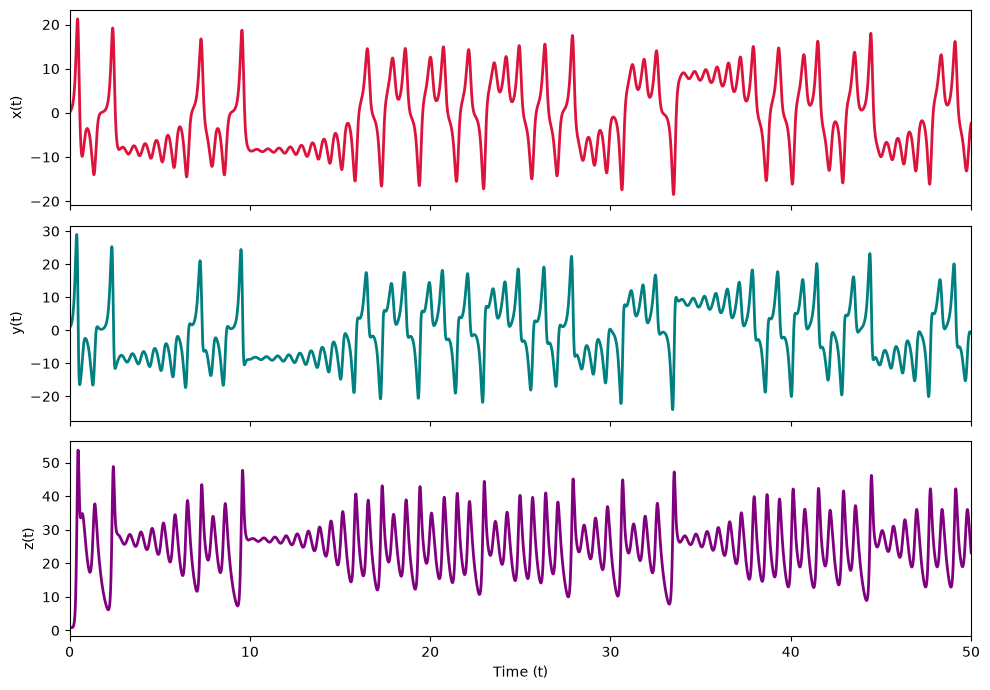

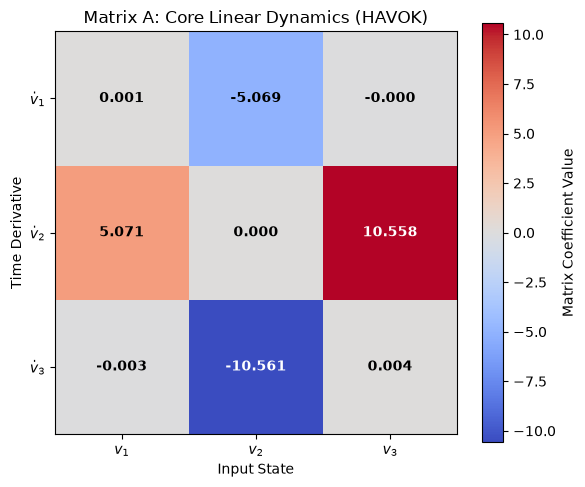

Matrix A shape: (3, 3) (Should be 3x3)
Matrix B shape: (3, 1) (Should be 3x1)

Matrix A:
 [[ 6.75826998e-04 -5.06916860e+00 -2.88487459e-05]
 [ 5.07068967e+00  3.25909983e-04  1.05579609e+01]
 [-3.37328987e-03 -1.05610503e+01  4.02675248e-03]]

Matrix B:
 [[ 1.01889106e-01]
 [-2.31306917e-05]
 [-1.48596210e+01]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.linalg import svd
# %matplotlib widget

def lorentz (xyz, s=10, r=28, b=2.667) :

    """
    Parameter
    ---------
    xyz : array, shape (3,)

    s,r,b : float
    Lorentz attarractor's parameter 
    """
    x,y,z = xyz
    x_dot = s*(y-x)
    y_dot = r*x - y -x*z
    z_dot = x*y - b*z

    return np.array([x_dot, y_dot, z_dot])

def generate_henon_x(num_steps=6000, a=1.4, b=0.3):
    x = np.zeros(num_steps)
    y = np.zeros(num_steps)
    for i in range(num_steps - 1):
        x[i+1] = 1 - a * x[i]**2 + y[i]
        y[i+1] = b * x[i]
    return x, y

def plot_lorentz ():
    dt = 0.01
    num_steps = 10000
    xyzs =np.empty((num_steps+1,3))
    xyzs[0] = (0.,1.0,1.05)

    for i in range(num_steps):
        xyzs[i+1] = xyzs[i] + lorentz(xyzs[i]) * dt

    x = xyzs[:,0]
    y = xyzs[:,1]
    z = xyzs[:,2]
    t = np.arange(num_steps + 1) * dt


    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, x, color="crimson", lw=2)
    axes[0].set_ylabel("x(t)")
    # axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, y, color="teal", lw=2)
    axes[1].set_ylabel("y(t)")
    # axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, z, color="purple", lw=2)
    axes[2].set_ylabel("z(t)")
    axes[2].set_xlabel("Time (t)")
    # axes[2].grid(True, alpha=0.3)

    plt.xlim(0, 50)
    plt.tight_layout()
    # plt.show()

    return x,y,z,t

def create_Hankel (m_dim , n_dim, x):

    first_col = x[:m_dim]
    last_row = x[m_dim-1:m_dim-1+n_dim]
    H = hankel(first_col, last_row)
    print("Original Hankel Matrix Shape:", H.shape)

    U,s,V = svd(H, full_matrices=False)
    print(f"U Matrix Shape : {U.shape}")
    print(f"s Matrix Shape : {s.shape}")
    print(f"V Matrix Shape : {V.shape}")



    return U,s,V

def trunc_Hankel (U,s,V,trunc_rank:int):
    new_U = U[:,:trunc_rank]
    new_s = s[:trunc_rank]
    new_V = V[:trunc_rank,:]

    print(f"U Matrix R rank Shape : {new_U.shape}")
    print(f"s Matrix R rank Shape : {new_s.shape}")
    print(f"V Matrix R rank Shape : {new_V.shape}")

    return new_U, new_s, new_V

def build_havok_linear_model(V_trunc, dt):
    """
    Builds the HAVOK forced linear model: v_dot = A * v + B * v_r
    """
    r = V_trunc.shape[0]
    
    # Step 1: Calculate the time derivative of the truncated V matrix
    # np.gradient provides a numerical approximation of the derivative
    dV_trunc = np.gradient(V_trunc, dt, axis=1)
    
    # Step 2: Partition the matrices into active state (v) and forcing term (v_r)
    v_state = V_trunc[:-1, :]    # First r-1 modes (Shape: 3x5000)
    v_force = V_trunc[-1:, :]    # Final r-th mode (Shape: 1x5000)
    dv_state = dV_trunc[:-1, :]  # Derivatives of the first r-1 modes (Shape: 3x5000)
    
    # Step 3: Stack state and forcing term vertically to form Theta (Shape: 4x5000)
    Theta = np.vstack([v_state, v_force])
    
    # Step 4: Solve the least-squares regression: Xi = dv_state * pseudo_inverse(Theta)
    # The @ symbol performs matrix multiplication
    Xi = dv_state @ np.linalg.pinv(Theta)
    
    # Step 5: Extract A and B from the combined operator Xi
    A = Xi[:, :-1]  # The (r-1) x (r-1) linear dynamics matrix
    B = Xi[:, -1:]  # The (r-1) x 1 forcing vector
    
    return A, B





x,y,z,timestep = plot_lorentz()

U,s,V = create_Hankel(m_dim=8, n_dim=5000, x=x)
U_trunc,s_trunc,V_trunc = trunc_Hankel(U,s,V,4)





print(f"Shape of U matrix: {U.shape}\n Shape of s matrix: {s.shape} \n Shape of V matrix: {V.shape}")

# Call the function using the dt=0.01 from your Lorenz generator
dt = 0.01
A, B = build_havok_linear_model(V_trunc, dt)

def plot_matrix_A_heatmap(A):
    """
    Plots the linear dynamics matrix A as an annotated heatmap.
    """
    plt.figure(figsize=(6, 5))
    
    # Use a diverging colormap (coolwarm) centered at zero to highlight positive/negative values
    max_val = np.max(np.abs(A))
    im = plt.imshow(A, cmap="coolwarm", vmin=-max_val, vmax=max_val)
    plt.colorbar(im, label="Matrix Coefficient Value")
    
    # Loop over data dimensions and create text annotations
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            # Change text color to white if the background is too dark for readability
            text_color = "white" if np.abs(A[i, j]) > max_val * 0.6 else "black"
            plt.text(j, i, f"{A[i, j]:.3f}",
                     ha="center", va="center", color=text_color, fontweight="bold")
            
    plt.title("Matrix A: Core Linear Dynamics (HAVOK)")
    
    # Label the axes mathematically
    plt.xticks(ticks=np.arange(A.shape[1]), labels=[f"$v_{{{i+1}}}$" for i in range(A.shape[1])])
    plt.yticks(ticks=np.arange(A.shape[0]), labels=[f"$\dot{{v}}_{{{i+1}}}$" for i in range(A.shape[0])])
    plt.xlabel("Input State")
    plt.ylabel("Time Derivative")
    
    plt.tight_layout()
    plt.show()

# Call the function using your previously generated matrix A
plot_matrix_A_heatmap(A)

print(f"Matrix A shape: {A.shape} (Should be 3x3)")
print(f"Matrix B shape: {B.shape} (Should be 3x1)")
print("\nMatrix A:\n", A)
print("\nMatrix B:\n", B)




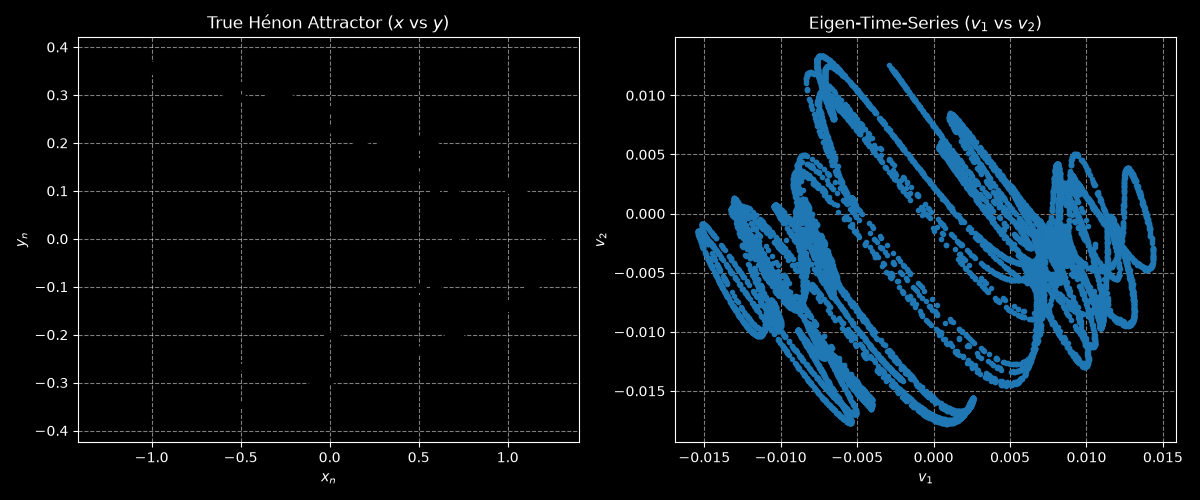

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel, svd
# %matplotlib widget


def generate_henon_x(num_steps=20000, a=1.4, b=0.3):
    x = np.zeros(num_steps)
    y = np.zeros(num_steps)
    for i in range(num_steps - 1):
        x[i+1] = 1 - a * x[i]**2 + y[i]
        y[i+1] = b * x[i]
    return x, y

# 1. Generate the data
x_henon, y_henon = generate_henon_x()

# 2. Build the Hankel Matrix (using just x)
m_dim = 8
n_dim = 15000
first_col = y_henon[:m_dim]
last_row = y_henon[m_dim-1 : m_dim-1+n_dim]
H = hankel(first_col, last_row)

# 3. Compute SVD
U, s, V = svd(H, full_matrices=False)

# 4. Plot True vs. SVD Reconstructed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Attractor (x vs y)
axes[0].plot(x_henon[m_dim-1 : m_dim-1+n_dim], y_henon[m_dim-1 : m_dim-1+n_dim], 
             '.', color="black", alpha=1)
axes[0].set_title("True Hénon Attractor ($x$ vs $y$)")
axes[0].set_xlabel("$x_n$")
axes[0].set_ylabel("$y_n$")
axes[0].grid(True, linestyle="--", alpha=0.5)

# SVD Reconstructed Attractor (v1 vs v2)
# CRITICAL: We use ',' (pixels) instead of lines for a discrete map
axes[1].plot(V[0, :], V[1, :], '.', color="tab:blue", alpha=1)
axes[1].set_title("Eigen-Time-Series ($v_1$ vs $v_2$)")
axes[1].set_xlabel("$v_1$")
axes[1].set_ylabel("$v_2$")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

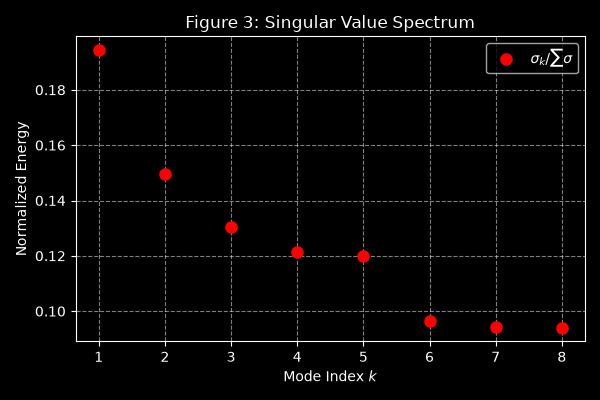

Error in callback <function flush_figures at 0x7f3f0366fce0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [24]:
plt.figure(figsize=(6, 4))
normalized_s = s / np.sum(s)
plt.plot(
    np.arange(1, len(s) + 1),
    normalized_s,
    "ro",
    markersize=8,
    label=r"$\sigma_k / \sum \sigma$",
)
plt.title("Figure 3: Singular Value Spectrum")
plt.xlabel("Mode Index $k$")
plt.ylabel("Normalized Energy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
# plt.show()


# Create a figure and a 2x3 grid layout
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3)

# Row 1, Middle (Column 1): True Lorenz Attractor
ax_true = fig.add_subplot(gs[0, 1])
ax_true.plot(x[8-1:8-1+5000], y[8-1:8-1+5000], color="crimson", lw=0.5)
ax_true.set_title("True Lorenz Attractor ($x$ vs $y$)")
ax_true.set_xlabel("$x(t)$")
ax_true.set_ylabel("$y(t)$")
ax_true.grid(True, linestyle="--", alpha=0.5)

# Row 2, Left (Column 0): v1 vs v2
ax_v12 = fig.add_subplot(gs[1, 0])
ax_v12.plot(V[0,:], V[1,:], color="tab:blue", lw=0.5)
ax_v12.set_title("Eigen-Time-Series ($v_1$ vs $v_2$)")
ax_v12.set_xlabel("$v_1$")
ax_v12.set_ylabel("$v_2$")
ax_v12.grid(True, linestyle="--", alpha=0.5)

# Row 2, Middle (Column 1): v2 vs v3
ax_v23 = fig.add_subplot(gs[1, 1])
ax_v23.plot(V[1,:], V[2,:], color="tab:orange", lw=0.5)
ax_v23.set_title("Eigen-Time-Series ($v_2$ vs $v_3$)")
ax_v23.set_xlabel("$v_2$")
ax_v23.set_ylabel("$v_3$")
ax_v23.grid(True, linestyle="--", alpha=0.5)

# Row 2, Right (Column 2): v3 vs v4
ax_v34 = fig.add_subplot(gs[1, 2])
ax_v34.plot(V[2,:], V[3,:], color="tab:green", lw=0.5)
ax_v34.set_title("Eigen-Time-Series ($v_3$ vs $v_4$)")
ax_v34.set_xlabel("$v_3$")
ax_v34.set_ylabel("$v_4$")
ax_v34.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.figure(figsize=(10,6))
plt.title("Lorentz $x(t)$ against V vector")
plt.plot(x, label="$x(t)$")
# plt.plot(500*V[0,:], lw=0.8)
# plt.plot(500*V[1,:], lw=0.8)
# plt.plot(500*V[2,:], lw=0.8)
plt.plot(900*V[3,:], lw=0.5)






# plt.show()

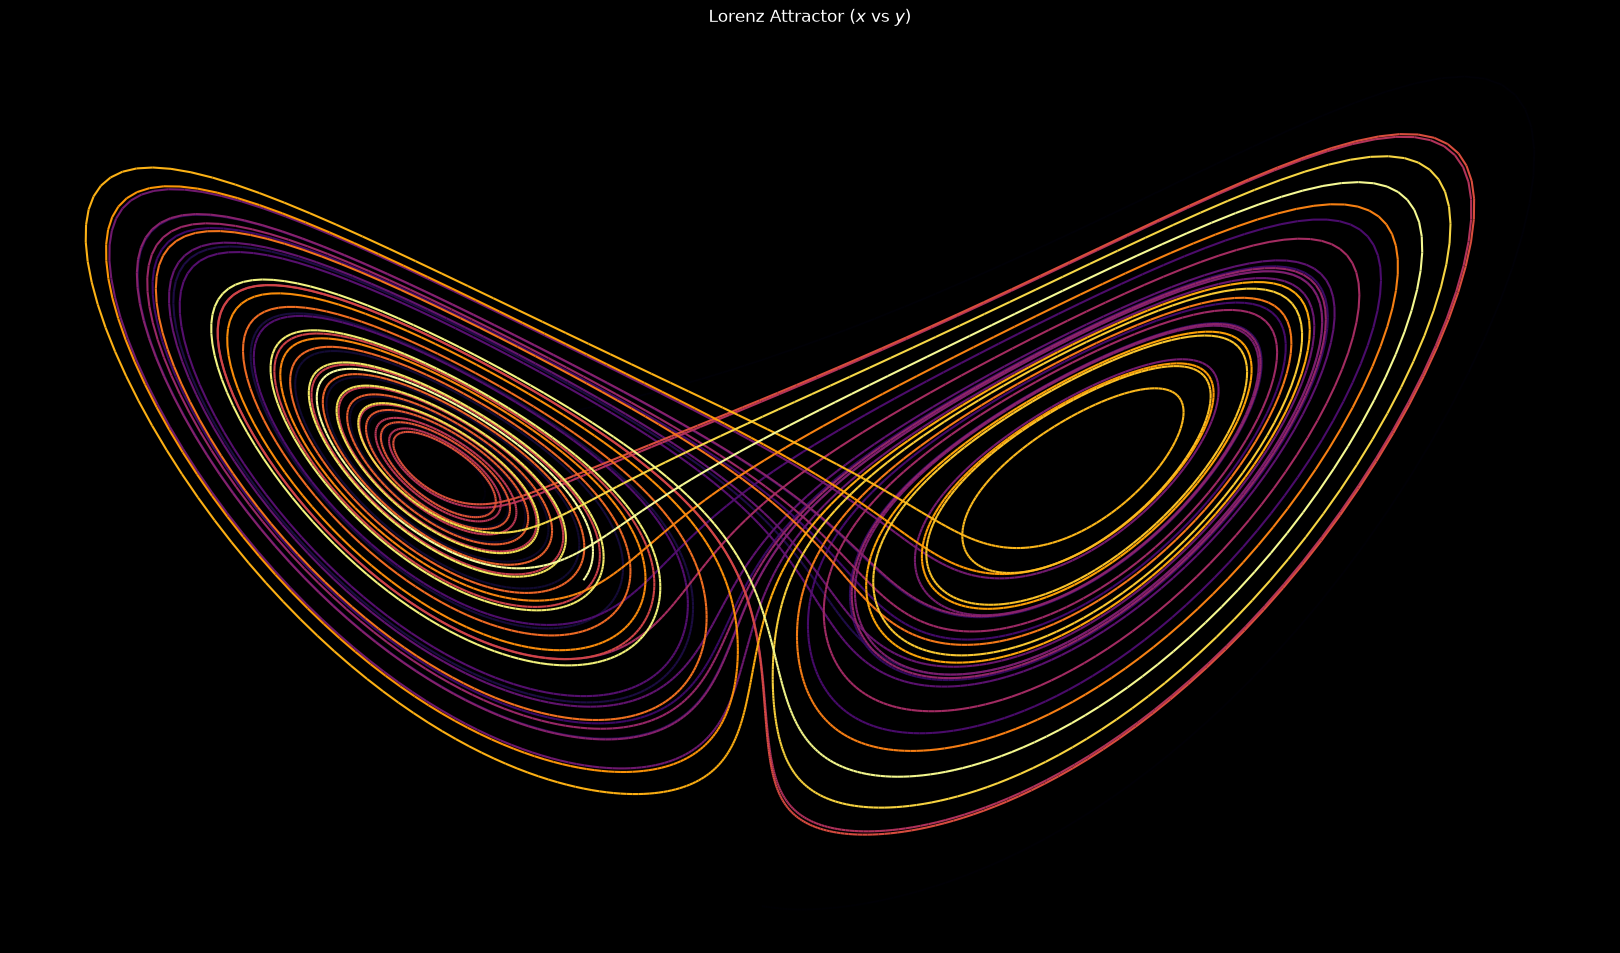

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

# 1. Generate the Lorenz Attractor Data
def lorenz(xyz, s=10, r=28, b=2.667):
    x, y, z = xyz
    x_dot = s * (y - x)
    y_dot = r * x - y - x * z
    z_dot = x * y - b * z
    return np.array([x_dot, y_dot, z_dot])

dt = 0.005
num_steps = 10000
xyzs = np.empty((num_steps + 1, 3))
xyzs[0] = (0., 1.0, 1.05)

for i in range(num_steps):
    xyzs[i+1] = xyzs[i] + lorenz(xyzs[i]) * dt

x = xyzs[:, 0]
y = xyzs[:, 1]
z = xyzs[:, 2]

# 2. Prepare the Line Segments for the Gradient
# Reshape the data so LineCollection can process it as individual segments
points = np.array([x, z]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 3. Setup the Figure and Axes
# Using a dark background makes the heat colormap stand out
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 9))

ax.set_xlim(x.min() - 2, x.max() + 2)
ax.set_ylim(z.min() - 2, z.max() + 2)
ax.set_title("Lorenz Attractor ($x$ vs $y$)", color='white', pad=15)
ax.set_xlabel("$x(t)$", color='white')
ax.set_ylabel("$y(t)$", color='white')
# ax.grid(True, alpha=0.1, color='white')

# 4. Initialize the LineCollection
# 'inferno' or 'hot' colormaps start dark/hot red and get warmer/brighter yellow
norm = mcolors.Normalize(vmin=0, vmax=num_steps)
lc = LineCollection([], cmap='inferno', norm=norm)
lc.set_linewidth(1.5)
ax.add_collection(lc)
ax.axis('off')
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
# 5. Define Animation Functions
def init():
    lc.set_segments([])
    return lc,

def update(frame):
    # Slice the segments up to the current frame
    current_segments = segments[:frame]
    lc.set_segments(current_segments)
    
    # Map the color array to the current time steps
    # This creates the gradient effect across the drawn line
    lc.set_array(np.arange(frame))
    return lc,

# Step 6. Run the Animation
# frame steps of 10 speed up the drawing process visually
ani = FuncAnimation(fig, update, frames=range(0, num_steps, 20),
                    init_func=init, blit=True, interval=20)


# Run the Animation
fps = 30
pause_seconds = 10
pause_frames = fps * pause_seconds  # 150 extra frames

# 1. Create the normal sequence of frames (using your step of 20)
frame_sequence = list(range(0, num_steps, 10))

# 2. Grab the very last frame number and duplicate it 150 times
last_frame = frame_sequence[-1]
frame_sequence.extend([last_frame] * pause_frames)

# 3. Pass this custom list into FuncAnimation
ani = FuncAnimation(fig, update, frames=frame_sequence,
                    init_func=init, blit=True, interval=20)

# 4. Save the GIF
ani.save('lorenz_background.gif', writer='pillow', fps=fps, dpi=80)